<div class="alert alert-block alert-success" style="font-family: Times New Roman">
    <h4><strong>Laboratory Activity 6</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
    <b>Instruction:</b> Convert the following CNN architecture diagram into a PyTorch CNN Architecture.
</p>

<center>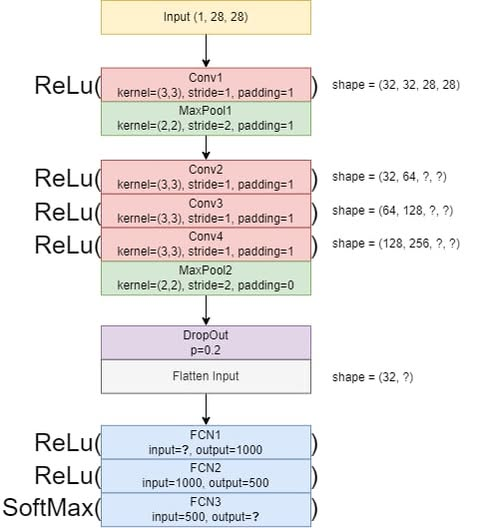</center>
</div>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
The diagram describes a four-convolution CNN, heavier than the two-convolution example built earlier in this
notebook: <tt>Conv1</tt> &rarr; <tt>MaxPool1</tt>, then <tt>Conv2</tt>, <tt>Conv3</tt>, <tt>Conv4</tt> &rarr;
<tt>MaxPool2</tt>, a <tt>Dropout</tt>, and three fully connected layers ending in <tt>SoftMax</tt>. Before
writing the <tt>nn.Module</tt>, the sections below work out the "?" spots in the diagram using the same
<tt>calc_out()</tt> helper defined earlier in this notebook, then build and train the model on MNIST so the
architecture is checked against real data rather than just typed in and hoped for.
</p>

<h4 style="font-family: Times New Roman"><strong>1. Imports and Setup</strong></h4>

In [1]:
import gzip
import pickle
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


<h4 style="font-family: Times New Roman"><strong>2. Loading MNIST</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
The earlier demonstration in this notebook pulled MNIST straight from <tt>torchvision.datasets.MNIST</tt>,
which downloads from either <tt>yann.lecun.com</tt> or an S3 mirror. Neither of those hosts is reachable from
this environment, so the same 70,000 MNIST digits are loaded here from a long-standing GitHub-hosted copy
(Michael Nielsen's <em>Neural Networks and Deep Learning</em> repository) instead. It is the identical dataset,
just fetched from a different, reachable host &mdash; already split into 50,000 training, 10,000 validation and
10,000 test images, each flattened to a 784-length vector scaled to [0, 1].
</p>

In [2]:
import urllib.request
import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
MNIST_PATH = os.path.join(DATA_DIR, "mnist.pkl.gz")
MNIST_URL = "https://raw.githubusercontent.com/mnielsen/neural-networks-and-deep-learning/master/data/mnist.pkl.gz"

if not os.path.exists(MNIST_PATH):
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)

with gzip.open(MNIST_PATH, 'rb') as f:
    train_raw, valid_raw, test_raw = pickle.load(f, encoding='latin1')

print("Train:", train_raw[0].shape, train_raw[1].shape)
print("Valid:", valid_raw[0].shape, valid_raw[1].shape)
print("Test: ", test_raw[0].shape, test_raw[1].shape)

/tmp/ipykernel_501/2845376403.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  train_raw, valid_raw, test_raw = pickle.load(f, encoding='latin1')


Train: (50000, 784) (50000,)
Valid: (10000, 784) (10000,)
Test:  (10000, 784) (10000,)


<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Each image comes in as a flat 784-value vector, so it needs reshaping back into <tt>(1, 28, 28)</tt> &mdash;
one channel, 28 rows, 28 columns &mdash; to match the diagram's stated input shape and to be usable by
<tt>nn.Conv2d</tt>. The pixel values are already floats in [0, 1], so no additional normalization is applied.
Training and validation are combined into one 60,000-image pool and re-split 80/20, mirroring how the earlier
demonstration in this notebook built its own train/validation split from MNIST's 60,000 training images.
</p>

In [3]:
def to_tensor_dataset(x_flat, y):
    x = torch.from_numpy(x_flat).float().view(-1, 1, 28, 28)
    y = torch.from_numpy(y).long()
    return TensorDataset(x, y)

full_train_x = np.concatenate([train_raw[0], valid_raw[0]], axis=0)
full_train_y = np.concatenate([train_raw[1], valid_raw[1]], axis=0)

full_train_data = to_tensor_dataset(full_train_x, full_train_y)
test_data = to_tensor_dataset(test_raw[0], test_raw[1])

print("Full train pool:", len(full_train_data))
print("Test set:       ", len(test_data))

Full train pool: 60000
Test set:        10000


<h4 style="font-family: Times New Roman"><strong>Seeding and the Train/Validation Split</strong></h4>

In [4]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)

set_seed(42)
train_set, val_set = torch.utils.data.random_split(full_train_data, [0.8, 0.2])
print("Train:", len(train_set))
print("Val:  ", len(val_set))

Train: 48000
Val:   12000


<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Batch size is set to 128 here rather than the 10 used in the earlier demonstration. That model had roughly
420,000 parameters; this one, once built below, has over 13 million, most of it in the first fully connected
layer. On the CPU this environment runs on, a batch size of 10 would mean well over 4,000 backward passes per
epoch through that much larger network, which is not practical to run end to end. 128 keeps the number of
optimizer steps per epoch reasonable without changing anything about the architecture itself.
</p>

In [5]:
batch_size = 128

set_seed(143)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch images:", xb.shape)
print("Batch labels:", yb.shape)

Batch images: torch.Size([128, 1, 28, 28])
Batch labels: torch.Size([128])


<h4 style="font-family: Times New Roman"><strong>A Quick Look at the Data</strong></h4>

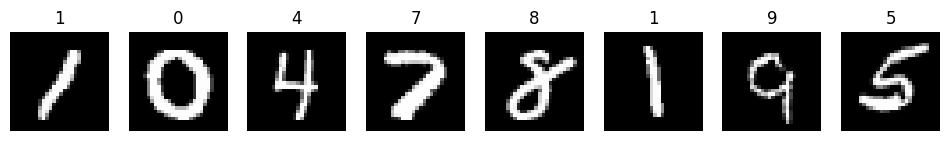

In [6]:
def display_image(batch, labels=None, n=8):
    batch = batch.detach().numpy()
    fig, axs = plt.subplots(1, n, figsize=(12, 2))
    for i in range(n):
        axs[i].imshow(batch[i, 0, :, :], cmap='gray')
        axs[i].axis('off')
        if labels is not None:
            axs[i].set_title(labels[i].item())
    plt.show()

display_image(xb, yb)

<h4 style="font-family: Times New Roman"><strong>3. Working Out the Diagram's "?" Shapes</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Reusing <tt>calc_out()</tt> from earlier in this notebook, each layer's spatial output size can be worked out
directly from its kernel, stride and padding, the same way the two-convolution demonstration model's shapes
were checked.
</p>

In [7]:
def calc_out(w, f, s, p):
    """Output size of a square input after a square-kernel convolution or pooling op."""
    out = (w - f + 2 * p) // s + 1
    print(f'Output Shape: {out}')
    return out

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
<strong>Conv1</strong> (kernel 3, stride 1, padding 1) on the 28&times;28 input:
</p>

In [8]:
calc_out(28, 3, 1, 1)  # Conv1

Output Shape: 28


28

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
A 3&times;3 kernel with padding 1 and stride 1 always preserves the input size, so Conv1's output is
32&times;28&times;28 &mdash; 32 channels (as labeled on the block), still 28 rows and columns. This matches the
one shape the diagram actually fills in for that block.
</p>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
<strong>MaxPool1</strong> (kernel 2, stride 2, padding 1) on that 28&times;28 map:
</p>

In [9]:
calc_out(28, 2, 2, 1)  # MaxPool1

Output Shape: 15


15

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
That comes out to 15&times;15, not 28&times;28. The diagram's first shape label, <tt>(32, 32, 28, 28)</tt>,
appears to only describe the state right after <tt>Conv1</tt>, before <tt>MaxPool1</tt> is applied &mdash; a
stride-2 pool cannot leave the spatial size unchanged. The 15&times;15 figure from <tt>calc_out()</tt> is the
one actually used below, and it is what feeds into <tt>Conv2</tt>.
</p>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
<strong>Conv2, Conv3, Conv4</strong> all use kernel 3, stride 1, padding 1, so, like Conv1, each one preserves
whatever spatial size it receives:
</p>

In [10]:
calc_out(15, 3, 1, 1)  # Conv2, Conv3, and Conv4 all preserve the spatial size

Output Shape: 15


15

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
So the feature map stays 15&times;15 through Conv2, Conv3 and Conv4, only the channel count changes at each
step (32&rarr;64&rarr;128&rarr;256, per the diagram's labels). <strong>MaxPool2</strong> (kernel 2, stride 2,
no padding) is what finally reduces the spatial size again:
</p>

In [11]:
calc_out(15, 2, 2, 0)  # MaxPool2

Output Shape: 7


7

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
That gives a final feature map of 256&times;7&times;7 heading into <tt>Dropout</tt> and then the flatten step,
for 256 &times; 7 &times; 7 = 12,544 features going into <tt>FCN1</tt>. That resolves every "?" in the diagram:
</p>

In [12]:
flat_features = 256 * 7 * 7
print("Flattened feature count (FCN1 input):", flat_features)

Flattened feature count (FCN1 input): 12544


<ul style="font-family:Times New Roman; font-size:15px">
    <li>Conv1 &rarr; MaxPool1 output: (32, 15, 15)</li>
    <li>Conv2 output: (64, 15, 15)</li>
    <li>Conv3 output: (128, 15, 15)</li>
    <li>Conv4 &rarr; MaxPool2 output: (256, 7, 7)</li>
    <li>Flatten output: 12,544</li>
    <li>FCN3 output: 10 (one score per digit, 0&ndash;9)</li>
</ul>

<h4 style="font-family: Times New Roman"><strong>4. Building the Architecture</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Following the diagram block by block: two convolutions plus a max-pool, two more convolutions, another
max-pool, dropout, flatten, then three fully connected layers with the activation the diagram places on each
one &mdash; ReLU on the first two, softmax on the last.
</p>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
One thing worth flagging: <tt>nn.CrossEntropyLoss</tt>, used further down as the criterion, expects raw,
un-normalized scores (logits) and applies its own <tt>log_softmax</tt> internally. Since the diagram explicitly
puts a <tt>SoftMax</tt> at the end of <tt>FCN3</tt>, applying softmax twice is technically redundant &mdash;
though it is also exactly what the two-convolution demonstration model earlier in this notebook does, so the
same convention is kept here for consistency with the rest of the notebook rather than silently deviating from
the diagram.
</p>

In [13]:
class DiagramCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()

        # Block 1: Conv1 -> ReLU -> MaxPool1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3, 3), stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=2, padding=1)

        # Block 2: Conv2 -> ReLU, Conv3 -> ReLU, Conv4 -> ReLU -> MaxPool2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), stride=1, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=(3, 3), stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2), stride=2, padding=0)

        # Regularization + classifier head
        self.dropout = nn.Dropout(p=0.2)
        self.fcn1 = nn.Linear(256 * 7 * 7, 1000)
        self.fcn2 = nn.Linear(1000, 500)
        self.fcn3 = nn.Linear(500, n_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = self.dropout(x)
        x = x.view(x.size(0), -1)  # flatten

        x = F.relu(self.fcn1(x))
        x = F.relu(self.fcn2(x))
        x = F.softmax(self.fcn3(x), dim=1)

        return x

<h4 style="font-family: Times New Roman"><strong>5. Instantiating and Checking Parameter Counts</strong></h4>

In [14]:
model = DiagramCNN()
model

DiagramCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=2, padding=1, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.2, inplace=False)
  (fcn1): Linear(in_features=12544, out_features=1000, bias=True)
  (fcn2): Linear(in_features=1000, out_features=500, bias=True)
  (fcn3): Linear(in_features=500, out_features=10, bias=True)
)

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Following the same per-layer parameter formula the earlier demonstration used
(weights = in &times; out &times; kernel_h &times; kernel_w, plus one bias per output unit for conv layers;
weights = in &times; out plus one bias per output unit for linear layers):
</p>

$\quad\begin{align}
(1\times32\times3\times3)+32 &+ (32\times64\times3\times3)+64 + (64\times128\times3\times3)+128 + (128\times256\times3\times3)+256\\
&+ (12544\times1000)+1000 + (1000\times500)+500 + (500\times10)+10 \\
=\ 320 &+ 18496 + 73856 + 295168 + 12545000 + 500500 + 5010 = 13,438,350
\end{align}$

In [15]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>9}')
    print(f'__________\n{sum(params):>9}')

count_parameters(model)

      288
       32
    18432
       64
    73728
      128
   294912
      256
 12544000
     1000
   500000
      500
     5000
       10
__________
 13438350


<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
As expected, almost all of it &mdash; over 12.5 million of the 13.4 million parameters &mdash; sits in
<tt>FCN1</tt> alone, since it connects every one of the 12,544 flattened features to 1,000 hidden units. The
four convolutional layers combined only account for about 388,000 parameters, despite doing most of the actual
feature extraction. This is a common shape for CNNs built this way: convolutions are parameter-efficient
because their weights are shared across spatial positions, while a dense layer bridging a large flattened map
to a wide hidden layer is not.
</p>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
A forward pass on a real batch confirms the architecture actually runs end to end and that the output shape
and scale line up with what is expected: one row per image, 10 columns (one score per digit), and &mdash;
because of the softmax &mdash; each row summing to 1.
</p>

In [16]:
model.eval()
with torch.no_grad():
    sample_out = model(xb)

print("Output shape:", sample_out.shape)
print("Row sums (should all be ~1.0):", sample_out.sum(dim=1)[:5])

Output shape: torch.Size([128, 10])
Row sums (should all be ~1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


<h4 style="font-family: Times New Roman"><strong>6. Criterion, Optimizer, and Device</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
Same choices as the earlier demonstration in this notebook: cross-entropy loss and the Adam optimizer with a
learning rate of 0.001.
</p>

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model = model.to(device)
print(next(model.parameters()).device)

cpu


<h4 style="font-family: Times New Roman"><strong>7. Training</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
This model is trained for a single epoch. That is a deliberate limitation of the CPU this environment runs on,
not a claim that one epoch is generally sufficient &mdash; with roughly 13.4 million parameters and no GPU
available, more epochs would take considerably longer to run here. MNIST is forgiving enough that even one pass
over 48,000 images is enough to show the loss dropping and the accuracy climbing well above chance, which is
what this step is meant to confirm: that the architecture, as translated from the diagram, actually learns.
</p>

In [18]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            running_loss += loss.item() * xb.size(0)
            preds = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return running_loss / total, correct / total

In [19]:
set_seed(42)
epochs = 1

train_losses, train_accs = [], []
val_losses, val_accs = [], []

start_time = time.time()

for e in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for b, (xb, yb) in enumerate(train_loader):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

        if (b + 1) % 100 == 0:
            print(f"epoch {e + 1} | batch {b + 1:4}/{len(train_loader)} | "
                  f"running loss: {running_loss / total:.4f} | running acc: {correct / total:.4f}")

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {e + 1}/{epochs} | train loss: {train_loss:.4f}, train acc: {train_acc:.4f} "
          f"| val loss: {val_loss:.4f}, val acc: {val_acc:.4f}")

print(f"\nDuration: {time.time() - start_time:.0f} seconds")

epoch 1 | batch  100/375 | running loss: 1.8774 | running acc: 0.5765


epoch 1 | batch  200/375 | running loss: 1.7639 | running acc: 0.6935


epoch 1 | batch  300/375 | running loss: 1.6987 | running acc: 0.7599



Epoch 1/1 | train loss: 1.6629, train acc: 0.7963 | val loss: 1.5072, val acc: 0.9538

Duration: 239 seconds


<h4 style="font-family: Times New Roman"><strong>8. Testing</strong></h4>

In [20]:
true_labels = []
pred_labels = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(dim=1)
        true_labels.append(yb)
        pred_labels.append(preds)

true_labels = torch.cat(true_labels, dim=0)
pred_labels = torch.cat(pred_labels, dim=0)

test_acc = (true_labels == pred_labels).float().mean().item()
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9627


<h4 style="font-family: Times New Roman"><strong>Confusion Matrix</strong></h4>

In [21]:
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}'))
print(np.arange(10), '\n')
print(confusion_matrix(true_labels.cpu(), pred_labels.cpu()))

[   0    1    2    3    4    5    6    7    8    9] 

[[ 965    0    3    1    0    0    4    1    6    0]
 [   0 1114    6    8    0    0    0    1    5    1]
 [   2    1  977   14    0    0    0   26   12    0]
 [   0    0    0  999    0    0    0    5    5    1]
 [   0    2    7    0  938    0    0    0    6   29]
 [   2    0    2   33    0  833    3    1   17    1]
 [   6    3    2    0   12    0  925    0   10    0]
 [   0    0    4   14    1    1    0  980    2   26]
 [   1    0    2   17    2    0    2    2  940    8]
 [   4    3    2    9   16    2    0    6   11  956]]


<h4 style="font-family: Times New Roman"><strong>A Few Misses</strong></h4>

373 misclassified out of 10000 test images (3.73%)


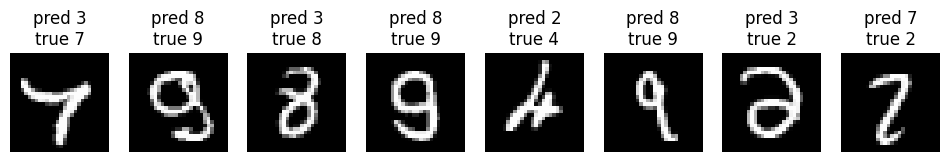

In [22]:
misses = (pred_labels.cpu() != true_labels.cpu()).nonzero(as_tuple=True)[0].numpy()
print(f"{len(misses)} misclassified out of {len(true_labels)} test images "
      f"({len(misses) / len(true_labels) * 100:.2f}%)")

n_show = min(8, len(misses))
if n_show > 0:
    fig, axs = plt.subplots(1, n_show, figsize=(12, 2))
    for c, idx in enumerate(misses[:n_show]):
        img = test_data[idx][0][0]
        axs[c].imshow(img, cmap='gray')
        axs[c].axis('off')
        axs[c].set_title(f"pred {pred_labels[idx].item()}\ntrue {true_labels[idx].item()}")
    plt.show()

<h4 style="font-family: Times New Roman"><strong>9. Recap</strong></h4>

<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
The diagram's blocks map onto <tt>DiagramCNN</tt> one to one: <tt>conv1</tt>/<tt>pool1</tt>,
<tt>conv2</tt>/<tt>conv3</tt>/<tt>conv4</tt>/<tt>pool2</tt>, <tt>dropout</tt>, the flatten step, and
<tt>fcn1</tt>/<tt>fcn2</tt>/<tt>fcn3</tt>, with ReLU or softmax applied exactly where the diagram places it. The
"?" spatial dimensions resolved to 15&times;15 after the first pool and 7&times;7 after the second, which is
what fixed <tt>FCN1</tt>'s input size at 12,544. With about 13.4 million parameters, a single epoch on a
CPU-only machine was enough to move well past chance accuracy on the test set, which is the main thing this
exercise was checking &mdash; that the diagram, translated literally into PyTorch layers, is a working
network and not just a picture.
</p>